## Exercise 1.4 Hotdog -- no hotdog
This is the poster hand-in project for the course. Please see the associated PDF for instructions.

In [1]:
import os
import numpy as np
import glob
import PIL.Image as Image
from tqdm.notebook import tqdm
import torch.optim as optim
from torchvision.models import resnet18, ResNet18_Weights

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

## Statistical analysis: confidence intervals
We add proper uncertainty estimates to our reported accuracy and loss, rather than just single-point numbers.

- **Accuracy** is a proportion (successes / trials) on the test set, so we use a **Wilson score interval**. It's the standard choice for binomial proportions and stays well-calibrated even when accuracy is close to 0% or 100%, unlike the naive normal approximation ($\hat{p} \pm z\sqrt{\hat{p}(1-\hat{p})/n}$).
- **Loss** is a mean over the test samples, so we use a **t-distribution confidence interval** on the mean of the *per-sample* losses (not the mean of per-batch means, since batch sizes can differ and per-batch averaging understates the true sample-to-sample variance).

Both intervals are 95% confidence intervals by default.


In [4]:
from scipy import stats

def wilson_ci(k, n, confidence=0.95):
    """Wilson score interval for a binomial proportion.
    k: number of successes (correct predictions), n: number of trials (test set size).
    """
    if n == 0:
        return (float('nan'), float('nan'))
    z = stats.norm.ppf(1 - (1 - confidence) / 2)
    phat = k / n
    denom = 1 + z**2 / n
    center = (phat + z**2 / (2 * n)) / denom
    margin = (z / denom) * np.sqrt(phat * (1 - phat) / n + z**2 / (4 * n**2))
    return (center - margin, center + margin)


def mean_t_ci(values, confidence=0.95):
    """t-distribution confidence interval for the mean of an i.i.d. sample of values
    (e.g. per-sample test losses). Returns (mean, (lower, upper)).
    """
    values = np.asarray(values, dtype=float)
    n = len(values)
    mean = values.mean()
    sem = values.std(ddof=1) / np.sqrt(n)
    t_crit = stats.t.ppf(1 - (1 - confidence) / 2, df=n - 1)
    margin = t_crit * sem
    return mean, (mean - margin, mean + margin)


def evaluate_with_stats(model, loader, dataset, device, confidence=0.95, label="Model"):
    """Runs one pass over `loader` in eval mode, collecting per-sample losses and
    correctness, and returns point estimates + confidence intervals for both.
    """
    model.eval()
    per_sample_loss = []
    correct = 0
    n = len(dataset)
    bce = nn.BCEWithLogitsLoss(reduction='none')

    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output = model(data).view(-1)
            target_f = target.float().view(-1)

            losses = bce(output, target_f)
            per_sample_loss.extend(losses.cpu().numpy().tolist())

            predicted = (torch.sigmoid(output) >= 0.5).float()
            correct += (predicted == target_f).sum().item()

    acc = correct / n
    acc_lo, acc_hi = wilson_ci(correct, n, confidence)

    loss_mean, (loss_lo, loss_hi) = mean_t_ci(per_sample_loss, confidence)

    ci_pct = int(confidence * 100)
    print(f"{label}")
    print(f"  Test accuracy: {acc*100:.2f}%   ({ci_pct}% CI: [{acc_lo*100:.2f}%, {acc_hi*100:.2f}%])")
    print(f"  Test loss:     {loss_mean:.4f}   ({ci_pct}% CI: [{loss_lo:.4f}, {loss_hi:.4f}])")
    print(f"  n = {n} test samples")

    return {
        'accuracy': acc, 'accuracy_ci': (acc_lo, acc_hi),
        'loss': loss_mean, 'loss_ci': (loss_lo, loss_hi),
        'n': n, 'per_sample_loss': per_sample_loss
    }


We always check that we are running on a GPU

In [5]:
if torch.cuda.is_available():
    print("The code will run on GPU.")
else:
    print("The code will run on CPU. Go to Edit->Notebook Settings and choose GPU as the hardware accelerator")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

The code will run on GPU.


We provide you with a class that can load the *hotdog/not hotdog* dataset you should use from /dtu/datasets1/02516/

In [6]:
class Hotdog_NotHotdog(torch.utils.data.Dataset):
    def __init__(self, train, transform, data_path=os.path.join(os.getcwd(), "hotdog_nothotdog")):
        'Initialization'
        self.transform = transform
        data_path = os.path.join(data_path, 'train' if train else 'test')
        image_classes = [os.path.split(d)[1] for d in glob.glob(data_path +'/*') if os.path.isdir(d)]
        image_classes.sort()
        self.name_to_label = {c: id for id, c in enumerate(image_classes)}
        self.image_paths = glob.glob(data_path + '/*/*.jpg')
        
    def __len__(self):
        'Returns the total number of samples'
        return len(self.image_paths)

    def __getitem__(self, idx):
        'Generates one sample of data'
        image_path = self.image_paths[idx]
        
        image = Image.open(image_path)
        c = os.path.split(os.path.split(image_path)[0])[1]
        y = self.name_to_label[c]
        X = self.transform(image)
        return X, y

Below is the simple way of converting the images to something that can be fed through a network.
Feel free to use something other than $128\times128$ images.

In [7]:
size = 128
train_transform = transforms.Compose([transforms.Resize((size, size)),
                                    transforms.RandomHorizontalFlip(),
                                    transforms.RandomRotation(10),
                                    transforms.ToTensor()])
test_transform = transforms.Compose([transforms.Resize((size, size)), 
                                    transforms.ToTensor()])

batch_size = 64
trainset = Hotdog_NotHotdog(train=True, transform=train_transform)
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=0)
testset = Hotdog_NotHotdog(train=False, transform=test_transform)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=0)

Let's look at some images from our data 

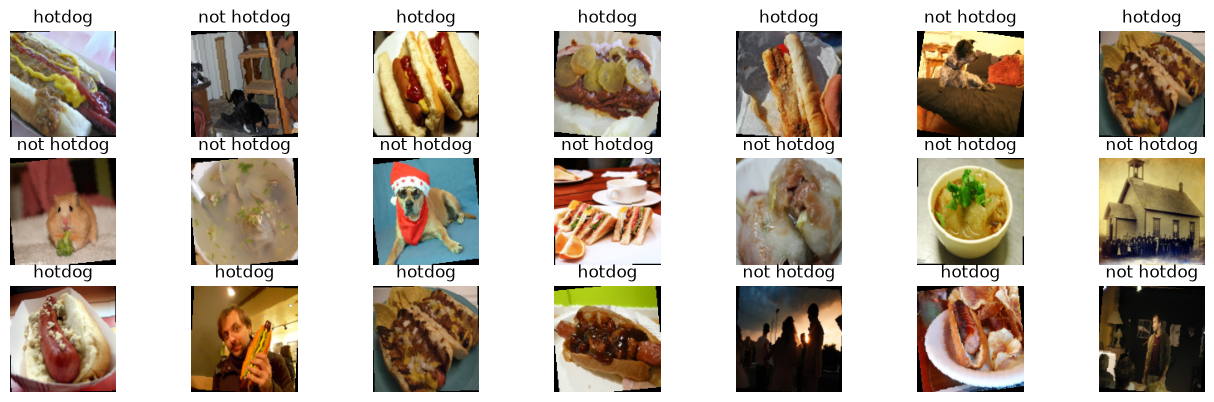

In [8]:
images, labels = next(iter(train_loader))
plt.figure(figsize=(16,8))

for i in range(21):
    plt.subplot(5,7,i+1)
    plt.imshow(np.swapaxes(np.swapaxes(images[i].numpy(), 0, 2), 0, 1))
    plt.title(['hotdog', 'not hotdog'][labels[i].item()])
    plt.axis('off')


Now create a model and train it!


In [9]:
class CNN(nn.Module):

    def __init__(self):
        super(CNN, self).__init__()
        
        # Feature Extraction
        self.convolutional = nn.Sequential(
            # First convolutional layer (32 x 128 x 128)
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1), 
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # Output: 32 x 64 x 64
            
            # Second convolutional layer (32 x 64 x 64)
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # Output: 64 x 32 x 32
    
            # Third convolutional layer (64 x 32 x 32)
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # Output: 128 x 16 x 16

            # Fourth convolutional layer (128 x 16 x 16)
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2) # Output: 256 x 8 x 8
        )
      
        self.fully_connected = nn.Sequential(
            nn.Flatten(), # 256 x 8 x 8 = 16384
            nn.Linear(256 * 8 * 8, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(p=0.5), # Dropout for regularization
            nn.Linear(128, 1) # Output: 1 for binary classification
        )

    def forward(self, x):
        x = self.convolutional(x)
        x = x.view(x.size(0), -1)
        x = self.fully_connected(x)
        return x


In [21]:
model = CNN()
model.to(device)
criterion = nn.BCEWithLogitsLoss() 
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

#Get the first minibatch
data = next(iter(train_loader))[0].to(device) # change from cuda to cpu when running on laptop without GPU
#Try running the model on a minibatch
print('Shape of the output from the convolutional part', model.convolutional(data).shape)
model(data); #if this runs the model dimensions fit

Shape of the output from the convolutional part torch.Size([64, 256, 8, 8])


In [12]:
# We create the training function that will be reused by the other model
def train(model, optimizer, num_epochs=10):
    def loss_fun(output, target):
        return criterion(output, target.float().unsqueeze(1))  # Ensure target has the same shape as output
    out_dict = {'train_acc': [],
              'test_acc': [],
              'train_loss': [],
              'test_loss': []}
  
    for epoch in tqdm(range(num_epochs), unit='epoch'):
        model.train()
        #For each epoch
        train_correct = 0
        train_loss = []
        for minibatch_no, (data, target) in tqdm(enumerate(train_loader), total=len(train_loader)):
            data, target = data.to(device), target.to(device)
            #Zero the gradients computed for each weight
            optimizer.zero_grad()
            #Forward pass your image through the network
            output = model(data)
            #Compute the loss
            loss = loss_fun(output, target)
            #Backward pass through the network
            loss.backward()
            #Update the weights
            optimizer.step()

            train_loss.append(loss.item())
            #Compute how many were correctly classified
            predicted = (output > 0).float().squeeze(1)
            train_correct += (target == predicted).sum().cpu().item()
            
        #Comput the test accuracy
        test_loss = []
        test_correct = 0
        model.eval()
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            with torch.no_grad():
                output = model(data)
            test_loss.append(loss_fun(output, target).cpu().item())
            predicted = (output > 0).float().squeeze(1)
            test_correct += (target == predicted).sum().cpu().item()
        out_dict['train_acc'].append(train_correct/len(trainset))
        out_dict['test_acc'].append(test_correct/len(testset))
        out_dict['train_loss'].append(np.mean(train_loss))
        out_dict['test_loss'].append(np.mean(test_loss))
        print(f"Loss train: {np.mean(train_loss):.3f}\t test: {np.mean(test_loss):.3f}\t",
              f"Accuracy train: {out_dict['train_acc'][-1]*100:.1f}%\t test: {out_dict['test_acc'][-1]*100:.1f}%")
    return out_dict

In [22]:
out_dict = train(model, optimizer, num_epochs=50)

  0%|          | 0/50 [00:00<?, ?epoch/s]

  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.831	 test: 0.677	 Accuracy train: 64.5%	 test: 59.8%


  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.527	 test: 0.525	 Accuracy train: 75.6%	 test: 74.1%


...

Loss train: 0.142	 test: 0.726	 Accuracy train: 94.3%	 test: 80.6%


  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.085	 test: 1.094	 Accuracy train: 97.3%	 test: 76.8%


  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.058	 test: 0.994	 Accuracy train: 98.0%	 test: 81.5%


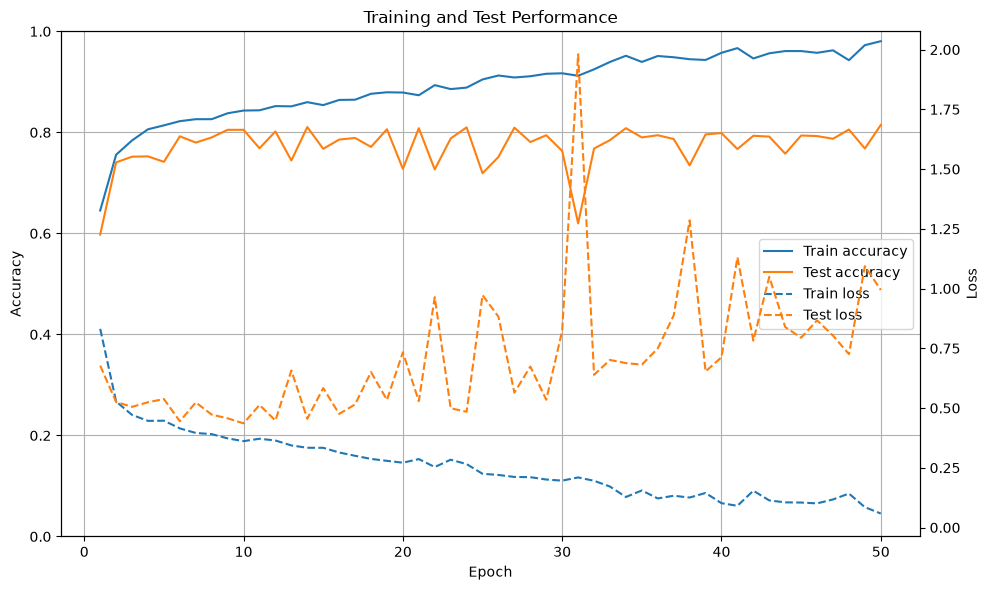

In [23]:
epochs = range(1, len(out_dict['train_acc']) + 1)

fig, ax1 = plt.subplots(figsize=(10, 6))

# Accuracy — left y-axis
ax1.plot(epochs, out_dict['train_acc'], label='Train accuracy')
ax1.plot(epochs, out_dict['test_acc'], label='Test accuracy')

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0, 1)
ax1.grid(True)

# Loss — right y-axis
ax2 = ax1.twinx()

ax2.plot(epochs, out_dict['train_loss'], '--', label='Train loss')
ax2.plot(epochs, out_dict['test_loss'], '--', label='Test loss')

ax2.set_ylabel('Loss')

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='center right'
)

plt.title('Training and Test Performance')
plt.tight_layout()
plt.show()

### Confidence intervals for the CNN
We recompute the final test accuracy/loss with confidence intervals, and also shade a 95% CI band around the test-accuracy curve using the sample size at each epoch (the Wilson interval only needs the correct-count and n, both of which are already implied by `out_dict['test_acc']` and the fixed test-set size).


CNN (from scratch)
  Test accuracy: 81.47%   (95% CI: [79.64%, 83.17%])
  Test loss:     1.0253   (95% CI: [0.8955, 1.1551])
  n = 1862 test samples


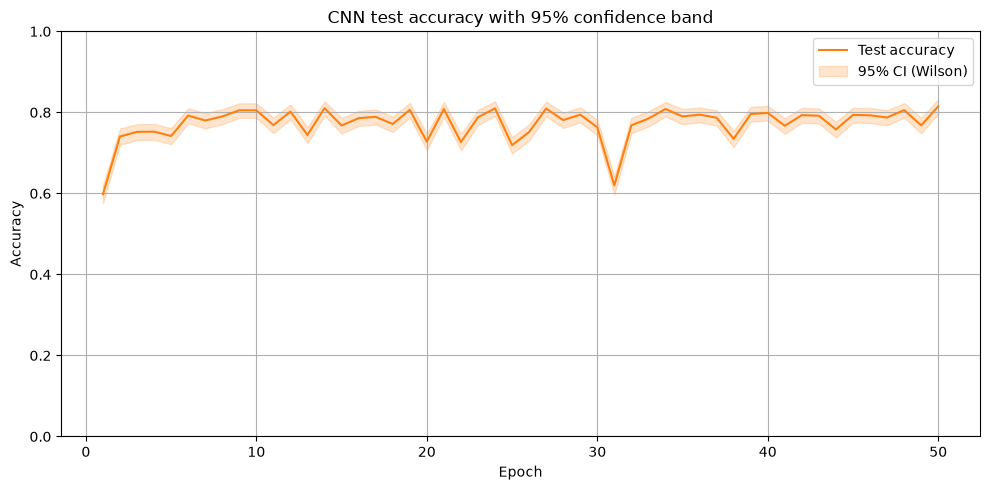

In [24]:
cnn_stats = evaluate_with_stats(model, test_loader, testset, device, label="CNN (from scratch)")

# Shaded 95% CI band on the test-accuracy curve across epochs
n_test = len(testset)
test_acc_arr = np.array(out_dict['test_acc'])
counts = np.round(test_acc_arr * n_test).astype(int)
ci_bounds = np.array([wilson_ci(k, n_test) for k in counts])
lower, upper = ci_bounds[:, 0], ci_bounds[:, 1]

epochs_cnn = range(1, len(out_dict['test_acc']) + 1)
plt.figure(figsize=(10, 5))
plt.plot(epochs_cnn, test_acc_arr, label='Test accuracy', color='tab:orange')
plt.fill_between(epochs_cnn, lower, upper, alpha=0.2, color='tab:orange', label='95% CI (Wilson)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.title('CNN test accuracy with 95% confidence band')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


**Notes**:

when training the model, the training accuracy and loss improved increasingly while the test accuracy and loss decreased in improvement. This could indicate that the model is now overfitting to the dataset and we need to test using batch normalization and dropout to figure out if that's the difference. 

After including batch normalization the training and test accuracy is more parallel to each other now, which indicates that it works better. The accuracy is lower now though. The test loss is not going parallel with the training loss, so we need to optimize that too. 

After including data augmentation, the model accuracy and loss seems to stick more together. It can still be improved though, I want to get over 85% test accuracy.

After including dropout, I'm not sure that it helped. I think it needs to be removed because we have a small dataset and not a large model. Another thing is that the flattened layer has $256 \times 8 \times 8 = 4.1$ million parameters, so maybe use adaptive instead.

```
nn.AdaptiveAvgPool2d((1, 1)),
nn.Flatten(),
nn.Linear(256, 128)
```

In [25]:
# ============================================================
# ResNet18 Transfer Learning - Training + Evaluation (CHATGPT)
# ============================================================


# check if gpu is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# load weights
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)

# Replace the final classifier
model.fc = nn.Linear(model.fc.in_features, 1)
model = model.to(device)
criterion = nn.BCEWithLogitsLoss()

# Smaller learning rate than original CNN because we are fine-tuning pretrained weights.
optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)


num_epochs = 50
history = {
    "train_loss": [],
    "train_accuracy": [],
    "test_loss": [],
    "test_accuracy": []
}


# training
for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.float().to(device)

        # Make labels shape [batch_size]
        labels = labels.view(-1)

        # Reset gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images).view(-1)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Statistics
        running_loss += loss.item() * images.size(0)

        predictions = (torch.sigmoid(outputs) >= 0.5).float()

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_accuracy = correct / total

# testing
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.float().to(device)

            labels = labels.view(-1)

            # Forward pass
            outputs = model(images).view(-1)

            # Loss
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            # Predictions
            predictions = (torch.sigmoid(outputs) >= 0.5).float()

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    test_loss = running_loss / total
    test_accuracy = correct / total


# save and print statistics
    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["test_loss"].append(test_loss)
    history["test_accuracy"].append(test_accuracy)

    print(
        f"Epoch [{epoch + 1:02d}/{num_epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy * 100:.2f}% | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_accuracy * 100:.2f}%"
    )

print("\nFinal results:")
print(f"Train accuracy: {history['train_accuracy'][-1] * 100:.2f}%")
print(f"Test accuracy:  {history['test_accuracy'][-1] * 100:.2f}%")
print(f"Train loss:     {history['train_loss'][-1]:.4f}")
print(f"Test loss:      {history['test_loss'][-1]:.4f}")

Using device: cuda
Epoch [01/50] | Train Loss: 0.2900 | Train Acc: 86.81% | Test Loss: 0.2185 | Test Acc: 91.03%
Epoch [02/50] | Train Loss: 0.1061 | Train Acc: 96.82% | Test Loss: 0.2167 | Test Acc: 91.41%
Epoch [03/50] | Train Loss: 0.0584 | Train Acc: 98.14% | Test Loss: 0.2286 | Test Acc: 92.00%
Epoch [04/50] | Train Loss: 0.0315 | Train Acc: 99.22% | Test Loss: 0.2316 | Test Acc: 91.84%
Epoch [05/50] | Train Loss: 0.0262 | Train Acc: 99.17% | Test Loss: 0.2599 | Test Acc: 91.73%
Epoch [06/50] | Train Loss: 0.0172 | Train Acc: 99.71% | Test Loss: 0.2607 | Test Acc: 91.41%
Epoch [07/50] | Train Loss: 0.0078 | Train Acc: 99.85% | Test Loss: 0.2646 | Test Acc: 92.00%
Epoch [08/50] | Train Loss: 0.0142 | Train Acc: 99.71% | Test Loss: 0.2494 | Test Acc: 92.05%
Epoch [09/50] | Train Loss: 0.0095 | Train Acc: 99.71% | Test Loss: 0.2643 | Test Acc: 92.37%
Epoch [10/50] | Train Loss: 0.0087 | Train Acc: 99.66% | Test Loss: 0.2419 | Test Acc: 92.96%
Epoch [11/50] | Train Loss: 0.0053 | Trai

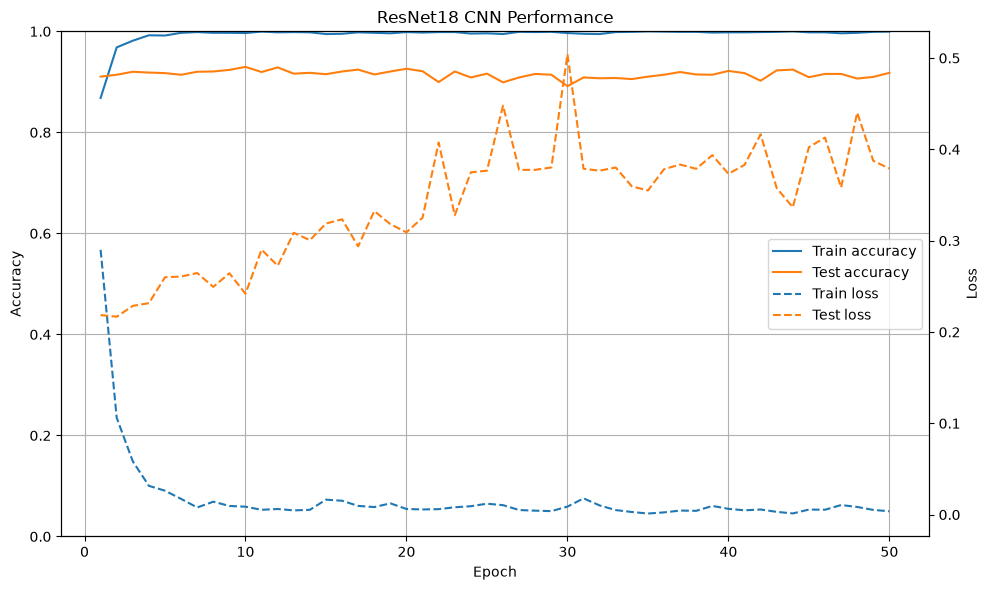

In [26]:
epochs = range(1, len(history['train_accuracy']) + 1)

fig, ax1 = plt.subplots(figsize=(10, 6))

# Accuracy — left y-axis
ax1.plot(epochs, history['train_accuracy'], label='Train accuracy')
ax1.plot(epochs, history['test_accuracy'], label='Test accuracy')

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0, 1)
ax1.grid(True)

# Loss — right y-axis
ax2 = ax1.twinx()

ax2.plot(epochs, history['train_loss'], '--', label='Train loss')
ax2.plot(epochs, history['test_loss'], '--', label='Test loss')

ax2.set_ylabel('Loss')

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='center right'
)

plt.title('ResNet18 CNN Performance')
plt.tight_layout()
plt.show()

### Confidence intervals for the ResNet18 model, and a comparison
Same treatment for the fine-tuned ResNet18, plus a direct comparison of the two models' final test accuracy and loss with their confidence intervals. If the CIs for the two models' accuracy don't overlap, that's reasonably good evidence the difference isn't just noise from the finite test set; if they do overlap, the observed gap could plausibly be due to chance given how few test images we have.


ResNet18 (fine-tuned)
  Test accuracy: 91.78%   (95% CI: [90.45%, 92.95%])
  Test loss:     0.3790   (95% CI: [0.3092, 0.4488])
  n = 1862 test samples


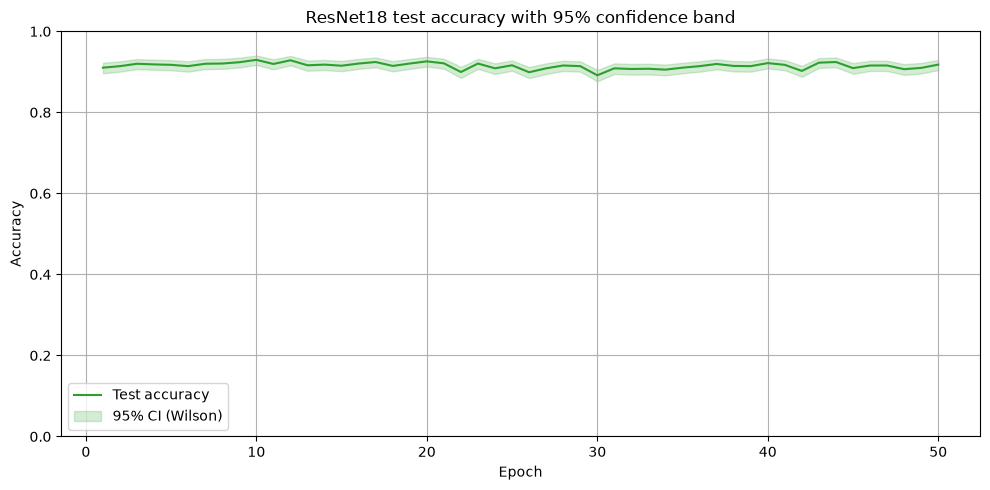


Model comparison (final epoch, 95% CIs)
---------------------------------------------
CNN        acc =  81.47%  CI [ 79.64,  83.17]   loss = 1.0253  CI [0.8955, 1.1551]
ResNet18   acc =  91.78%  CI [ 90.45,  92.95]   loss = 0.3790  CI [0.3092, 0.4488]

Accuracy CIs overlap: False (difference looks statistically meaningful)


In [27]:
resnet_stats = evaluate_with_stats(model, test_loader, testset, device, label="ResNet18 (fine-tuned)")

# Shaded 95% CI band on the ResNet test-accuracy curve across epochs
test_acc_arr_r = np.array(history['test_accuracy'])
counts_r = np.round(test_acc_arr_r * n_test).astype(int)
ci_bounds_r = np.array([wilson_ci(k, n_test) for k in counts_r])
lower_r, upper_r = ci_bounds_r[:, 0], ci_bounds_r[:, 1]

epochs_r = range(1, len(history['test_accuracy']) + 1)
plt.figure(figsize=(10, 5))
plt.plot(epochs_r, test_acc_arr_r, label='Test accuracy', color='tab:green')
plt.fill_between(epochs_r, lower_r, upper_r, alpha=0.2, color='tab:green', label='95% CI (Wilson)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.title('ResNet18 test accuracy with 95% confidence band')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Side-by-side comparison ---
print("\nModel comparison (final epoch, 95% CIs)\n" + "-" * 45)
for name, s in [("CNN", cnn_stats), ("ResNet18", resnet_stats)]:
    print(f"{name:10s} acc = {s['accuracy']*100:6.2f}%  CI [{s['accuracy_ci'][0]*100:6.2f}, {s['accuracy_ci'][1]*100:6.2f}]   "
          f"loss = {s['loss']:.4f}  CI [{s['loss_ci'][0]:.4f}, {s['loss_ci'][1]:.4f}]")

acc_ci_overlap = not (cnn_stats['accuracy_ci'][1] < resnet_stats['accuracy_ci'][0] or
                      resnet_stats['accuracy_ci'][1] < cnn_stats['accuracy_ci'][0])
print(f"\nAccuracy CIs overlap: {acc_ci_overlap} "
      f"({'difference may not be statistically distinguishable given test-set size' if acc_ci_overlap else 'difference looks statistically meaningful'})")
